####**Project Objective**

####Sentiment Analysis on Movie Reviews Using Machine Learning and Natural Language Processing

The objective of this project is to develop an intelligent sentiment analysis system that automatically classifies movie reviews as positive, negative, or neutral based on the textual content of the reviews. The project aims to apply Natural Language Processing (NLP) techniques for text preprocessing and feature extraction, and to evaluate the performance of different machine learning and deep learning models in predicting sentiment accurately.

The system will preprocess raw text data, convert textual information into numerical representations using techniques such as TF-IDF, and train classification models including Logistic Regression, Support Vector Machines (SVM), and Transformer-based models such as BERT. The project also aims to compare the performance of these approaches and analyze misclassified reviews to understand model limitations and improve prediction quality.

####**Dataset source**
Number of records: 50,000

Features:
review → movie review text
sentiment → positive/negative
Class distribution

Visualizations

Create:

Bar chart of sentiment distribution

Review length distribution

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
movie_dataset = pd.read_csv('/content/IMDB Dataset.csv', engine="python",  on_bad_lines="skip")

In [ ]:
movie_dataset.shape

(50000, 2)

In [ ]:
movie_dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
movie_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
movie_dataset.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
movie_dataset['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


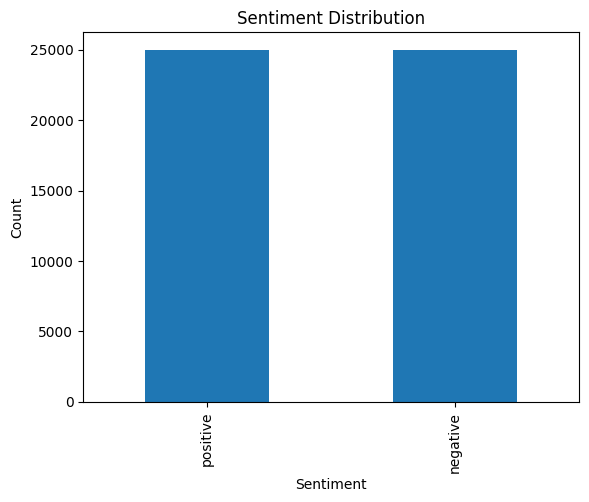

In [ ]:
movie_dataset['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
movie_dataset['review_length'] = movie_dataset['review'].apply(len)

movie_dataset[['review_length']].head()

,review_length
0,1761
1,998
2,926
3,748
4,1317


In [ ]:
movie_dataset['review_length'].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


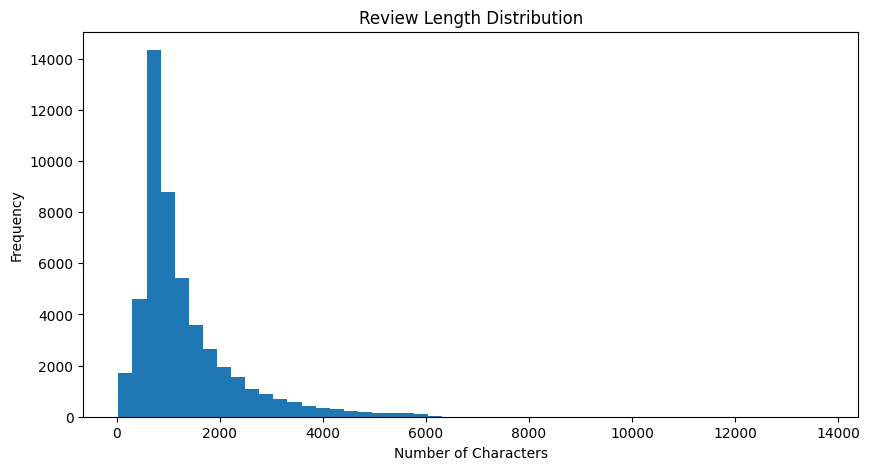

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(movie_dataset['review_length'], bins=50)

plt.title('Review Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')

plt.show()

The IMDb Movie Reviews Dataset contains 50,000 movie reviews labeled as positive or negative sentiments. The dataset is balanced, with 25,000 positive reviews and 25,000 negative reviews. Each record consists of the review text and its corresponding sentiment label. The dataset is widely used for sentiment analysis and natural language processing tasks.

In [ ]:
!pip install nltk

NLTK (Natural Language Toolkit) is a Python library for working with human language (text). Since sentiment analysis deals with text reviews, NLTK provides tools to clean and prepare that text before machine learning.

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
#Download NLTK Resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
  #this converts text to lower case
  text = text.lower()
  #remove html tags
  text = re.sub(r'<br\s*/?>', ' ', text)
  # 3. Keep only alphabetic characters (Removes punctuation and numbers)
  text = re.sub(r'[^a-z\s]', '', text)
  #tokenize
  words = text.split()
  #remove stopwards + lemmatization
  words = [
      lemmatizer.lemmatize(word)
      for word in words
      if word not in stop_words
  ]
  return" ".join(words)

A Lemmatizer is a tool that breaks a word down to its "dictionary form"—the most basic, meaningful version of the word. In linguistics, this base form is called a Lemma.

In [ ]:
#Testing on one review
sample_review = movie_dataset['review'][0]
print("original Review:")
print(sample_review[:500])
print("\nprocessed Review:")
print(preprocess_text(sample_review[:500]))


original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

processed Review:
one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz


In [ ]:
#Applying to entire data set
movie_dataset['clean_review'] = movie_dataset['review'].apply(preprocess_text)

In [ ]:
#verifying the results
movie_dataset[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [ ]:
# saving to processed data
movie_dataset.to_csv('imdb_cleaned.csv', index=False)

In [ ]:
!pip install wordcloud

In [ ]:
#A Word Cloud visually shows the most frequent words in reviews
from wordcloud import WordCloud

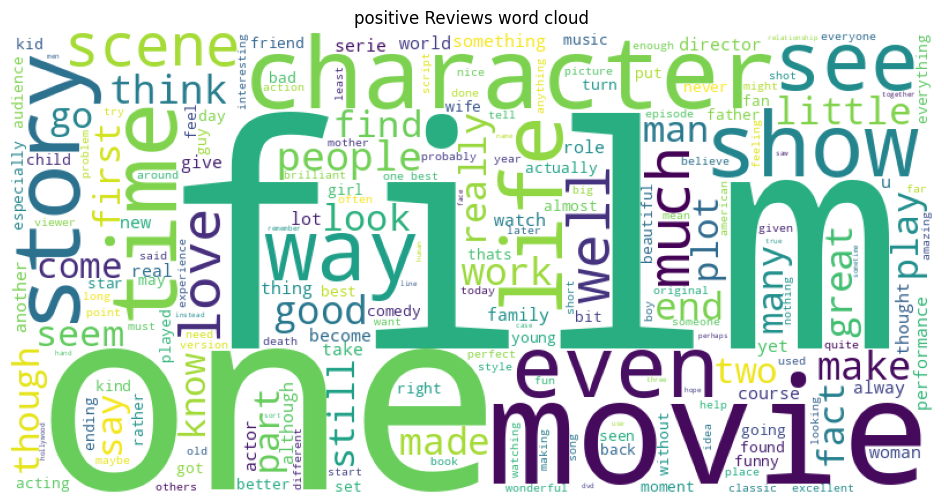

In [ ]:
positive_reviews = " ".join(
    movie_dataset[movie_dataset['sentiment'] == 'positive']['clean_review']
)
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = 'white'
).generate(positive_reviews)
plt.figure(figsize = (12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("positive Reviews word cloud")
plt.show()

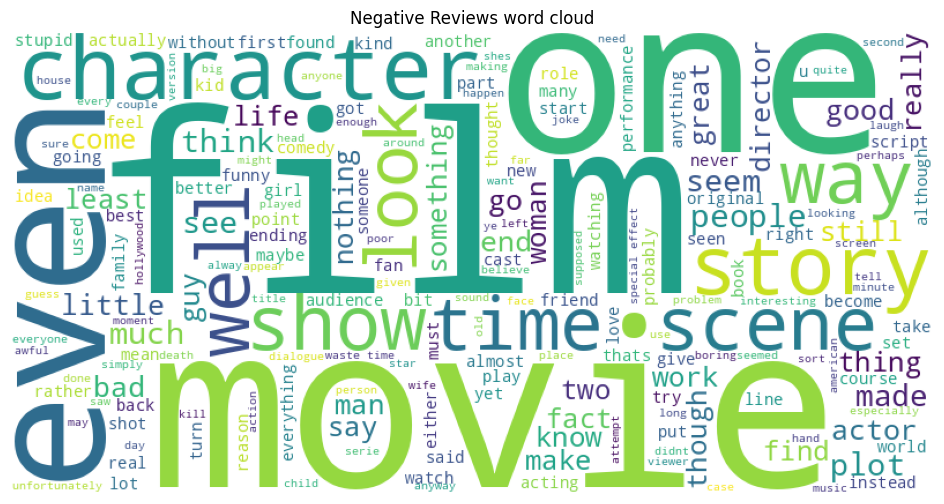

In [ ]:
#Negative reviews
negative_reviews = " ".join(
    movie_dataset[movie_dataset['sentiment']=='negative']['clean_review']
)
wordcloud = WordCloud(
width = 800,
height =400,
background_color = 'white'
).generate(negative_reviews)
plt.figure(figsize = (12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews word cloud")
plt.show()

In [ ]:
#count how many times items appear in a collection (like a list of words).
from collections import Counter

In [ ]:
#positive reviews
positive_words = " ".join(
    movie_dataset[movie_dataset['sentiment'] == 'positive']['clean_review']
).split()
positive_freq = Counter(positive_words)
positive_freq.most_common(20)

[('film', 48751),
 ('movie', 43925),
 ('one', 27535),
 ('like', 17664),
 ('time', 15639),
 ('good', 14642),
 ('story', 13912),
 ('character', 13827),
 ('great', 12860),
 ('see', 12650),
 ('well', 11507),
 ('get', 11129),
 ('make', 11009),
 ('also', 10729),
 ('really', 10720),
 ('would', 10383),
 ('scene', 9882),
 ('show', 9536),
 ('even', 9487),
 ('life', 9382)]

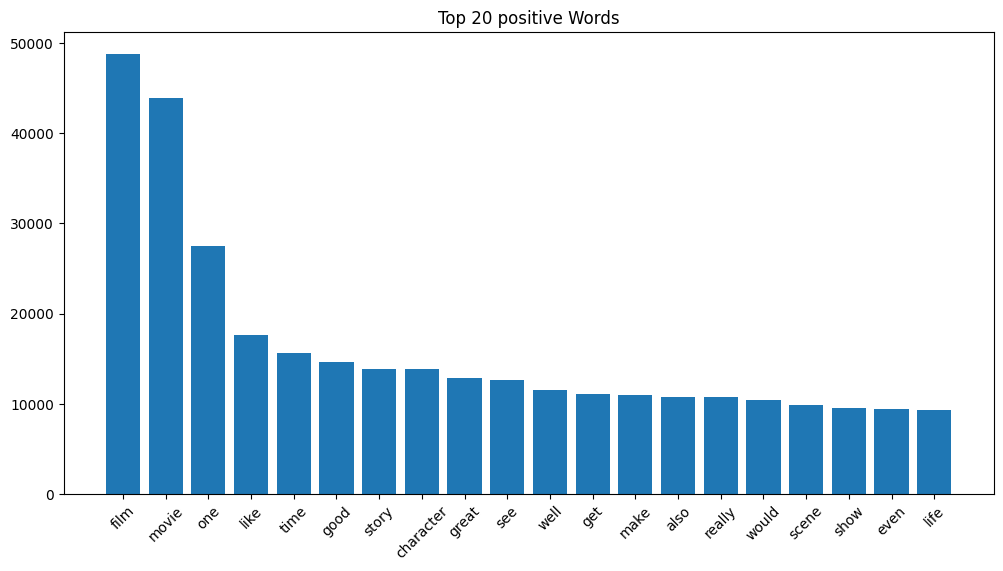

In [ ]:
top_words = positive_freq.most_common(20)
words = [word for word, count in top_words]
counts = [count for word, count in top_words]
plt.figure(figsize = (12,6))
plt.bar(words, counts)
plt.xticks(rotation = 45)
plt.title("Top 20 positive Words")
plt.show()

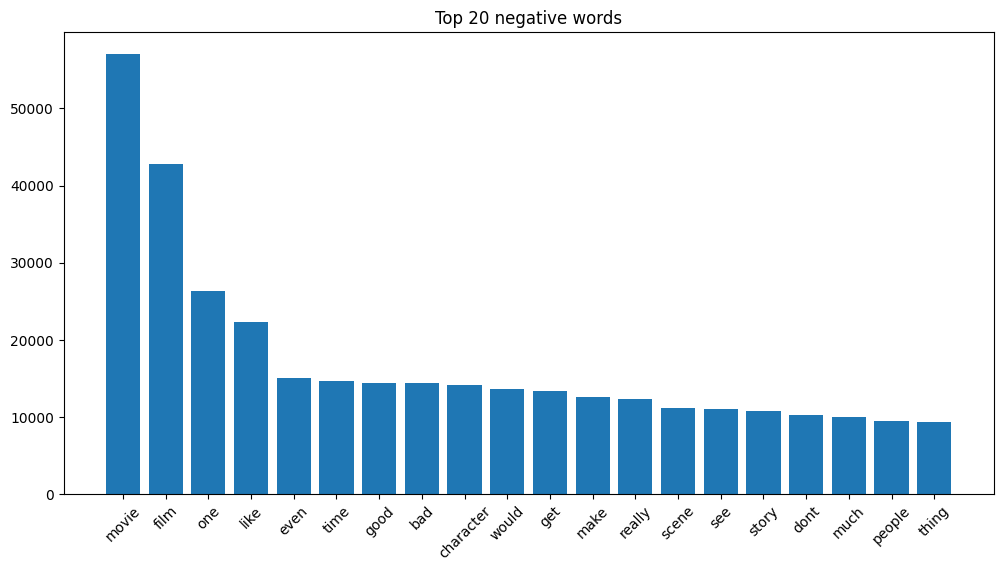

In [ ]:
Negative_words = " ".join(
    movie_dataset[movie_dataset['sentiment'] == 'negative']['clean_review']
).split()
negative_freq = Counter(Negative_words)
top_words = negative_freq.most_common(20)
words = [word for word, count in top_words]
counts = [count for word, count in top_words]
plt.figure(figsize = (12,6))
plt.bar(words, counts)
plt.xticks(rotation = 45)
plt.title("Top 20 negative words")
plt.show()

####**TF-IDF Feature Extraction**

In [ ]:
#Machine learning models cannot understand text directly. We need to convert the cleaned reviews into numerical vectors.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#converting text into TF-IDF Features
tfidf = TfidfVectorizer(max_features = 5000)
x =  tfidf.fit_transform(movie_dataset['clean_review'])
y = movie_dataset['sentiment']

In [ ]:
print(x.shape)

(50000, 5000)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
Lr_model = LogisticRegression(max_iter = 1000)

In [ ]:
Lr_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = Lr_model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8857


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000




Overall Performance
The Logistic Regression model achieved an overall accuracy of 89% on the test dataset of 10,000 reviews. The dataset is nearly perfectly balanced, with 4,961 negative reviews and 5,039 positive reviews.

Class Breakdown

1.  Negative Reviews

  - Precision (90%): Out of all the reviews the model predicted as negative, 90% were actually negative.
  - Recall (87%): Out of all the actual negative reviews in the dataset, the model correctly found 87% of them.
  - F1-Score (88%): A strong, balanced score indicating minimal false alarms and missed negatives.

2.  Positive Reviews

  - Precision (88%): Out of all the reviews the model predicted as positive, 88% were actually positive.
  - Recall (90%): Out of all the actual positive reviews in the dataset, the model successfully caught 90% of them.
  - F1-Score (89%): Excellent performance, showing the model is slightly better at capturing all positive sentiments compared to negatives.

Key Takeaways for Project Report

  - The model shows no bias toward either class. Both macro and weighted averages are tied directly at 89%.
  - The model is exceptionally reliable, making it highly suitable for classifying Kaggle movie/TV review sentiments.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4325  636]
 [ 507 4532]]


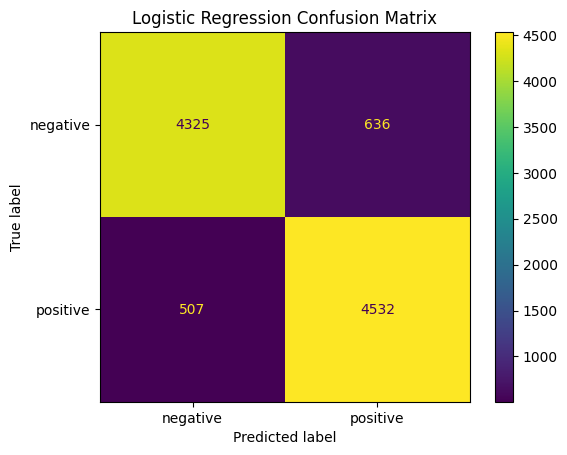

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
review = [
    "this movie was fantastic. The acting was brilliant and i enjoyed every minute"
]
review_clean = preprocess_text(review[0])
review_vector = tfidf.transform([review_clean])
prediction = Lr_model.predict(review_vector)
print("predicted sentiment:", prediction[0])

predicted sentiment: positive


In [ ]:
review = [
    "This was the worst movie I have ever watched."
]
review_clean = preprocess_text(review[0])
review_vector = tfidf.transform([review_clean])
prediction = Lr_model.predict(review_vector)
print("prediction sentiment:", prediction[0])

prediction sentiment: negative


####**Training another model and compare it with Logistic Regression.**

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm_model = LinearSVC()
svm_model.fit(x_train, y_train)
svm_pred = svm_model.predict(x_test)

In [ ]:
from sklearn.metrics import *

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_pred)

In [ ]:
classification_report = classification_report(y_test, svm_pred)
print(classification_report)

              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4961
    positive       0.88      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Breaking Down the SVM Scores
1. Negative Reviews (F1-Score: 0.88)
Precision (89%): Out of all reviews the SVM guessed were negative, 89% actually were. It has a low false-alarm rate.

Recall (87%): It successfully captured 87% of all the actual negative reviews in the dataset.

2. Positive Reviews (F1-Score: 0.88)
Precision (88%): Out of all reviews the SVM guessed were positive, 88% were correct.

Recall (89%): It successfully caught 89% of all actual positive reviews.

In [ ]:
svccm = confusion_matrix(y_test, svm_pred)
print(svccm)

[[4325  636]
 [ 549 4490]]


4,326 True Negatives: The SVM correctly identified 4,326 bad reviews.

4,490 True Positives: The SVM correctly identified 4,490 good reviews.

635 False Positives: These were actually negative reviews, but the SVM mistakenly guessed they were Positive.

549 False Negatives: These were actually positive reviews, but the SVM mistakenly guessed they were Negative.

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool.

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
#testing on sample review
review = "this movie was fantastic  and exciting"
score = analyzer.polarity_scores(review)
print(score)

{'neg': 0.0, 'neu': 0.37, 'pos': 0.63, 'compound': 0.7783}


In [ ]:
def vader_predict(review):
  score = analyzer.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return 'positive'
  elif compound <= -0.05:
    return 'negative'
  else:
    return 'neutral'

In [ ]:
vader_predict("This movie was amazing")

'positive'

In [ ]:
movie_dataset['vader_predict'] = movie_dataset['review'].apply(vader_predict)

In [ ]:
from sklearn.metrics import *

In [ ]:
vader_accuracy = accuracy_score(
    movie_dataset['sentiment'],
    movie_dataset['vader_predict']
)
print("vader accuracy:", vader_accuracy)

vader accuracy: 0.69226


In [ ]:
#classification report
print(
    classification_report(
        movie_dataset['sentiment'],
        movie_dataset['vader_predict']
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.79      0.53      0.63     25000
     neutral       0.00      0.00      0.00         0
    positive       0.65      0.86      0.74     25000

    accuracy                           0.69     50000
   macro avg       0.48      0.46      0.46     50000
weighted avg       0.72      0.69      0.69     50000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


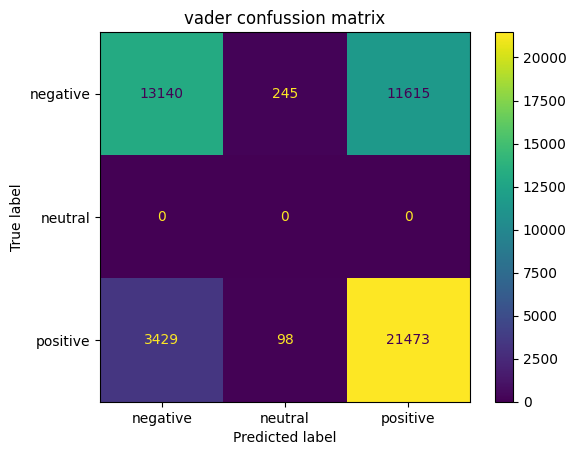

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    movie_dataset['sentiment'],
    movie_dataset['vader_predict']
)
plt.title("vader confussion matrix")
plt.show()

Here our model VADER correctly classified many negative reviews (13,140).

It correctly classified many positive reviews as well (around 21k+).

Some positive reviews were predicted as negative (3,429).

Some negative reviews were predicted as positive (around 11615).

##**Report Note:**

VADER was evaluated as a rule-based sentiment analysis approach and compared against machine learning models. Although it provided reasonable sentiment predictions without requiring training data, its performance was lower than Logistic Regression and SVM. This indicates that machine learning models are better able to capture complex contextual information present in movie reviews.

In [ ]:
#Error analysis

In [ ]:
results = pd.DataFrame({
    'review' : movie_dataset.loc[y_test.index, 'review'],
    'actual' : y_test,
    'predicted' : y_pred
})
misclassified = results[results['actual']!= results['predicted']]
misclassified.head(10)

,review,actual,predicted
33553,I really liked this Summerslam due to the look...,positive,negative
49498,"Okay, I didn't get the Purgatory thing the fir...",positive,negative
29282,This movie starts off somewhat slowly and gets...,positive,negative
6113,"The production quality, cast, premise, authent...",positive,negative
15118,"This movie was released originally as a soft ""...",positive,negative
33109,Three kids are born during a solar eclipse and...,positive,negative
22062,Though I can't claim to be a comic book fanati...,positive,negative
43824,Although this series and the mini film in part...,negative,positive
34657,"In fact, parts of it I liked a lot. It had som...",negative,positive
20304,"It's awesome! In Story Mode, your going from p...",positive,negative


In [ ]:
!pip install transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


How DistilBERT Works?

DistilBERT is based on the transformer architecture and processes text bidirectionally, meaning it understands a word by considering both the left and right context in a sentence. During training, the smaller DistilBERT model learns from the predictions of a larger pre-trained BERT model, allowing it to capture much of BERT’s language understanding capability while remaining compact.

In [ ]:
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
movie_dataset_bert = movie_dataset[['clean_review', 'sentiment' ]].copy()
movie_dataset_bert['label'] = movie_dataset_bert['sentiment'].map({
    'negative' : 0,
    'positive': 1
})
movie_dataset.head()

,review,sentiment,review_length,clean_review,vader_predict
0,One of the other reviewers has mentioned that ...,positive,1761,one reviewer mentioned watching oz episode you...,negative
1,A wonderful little production. <br /><br />The...,positive,998,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,negative,748,basically there family little boy jake think t...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter matteis love time money visually stunni...,positive


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_movie_dataset, test_movie_dataset = train_test_split(
    movie_dataset_bert,
    test_size = 0.2,
    random_state = 42
)

In [ ]:
# convert to Hugging face dataset

In [ ]:
train_dataset = Dataset.from_pandas(train_movie_dataset)
test_dataset = Dataset.from_pandas(test_movie_dataset)

In [ ]:
#Loading Distilbert tokenizer

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#Tokenize Review
def tokenize_function(example):
  return tokenizer(
      example['clean_review'],
      truncation = True,
      padding = "max_length",
      max_length = 512
  )
train_dataset = train_dataset.map(tokenize_function, batched = True)
test_dataset = test_dataset.map(tokenize_function, batched = True)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = 2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Training Arguments
training_args = TrainingArguments(
    output_dir = "./results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    num_train_epochs = 1,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.229436,0.227857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.28682811279296877, metrics={'train_runtime': 2171.5403, 'train_samples_per_second': 18.42, 'train_steps_per_second': 1.151, 'total_flos': 5298695946240000.0, 'train_loss': 0.28682811279296877, 'epoch': 1.0})

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch
0.229436,0.227857,1


{'eval_loss': 0.22785739600658417}

In [ ]:
predictions = trainer.predict(test_dataset)

In [ ]:
import numpy as np

y_pred_bert = np.argmax(predictions.predictions, axis=1)

In [ ]:
y_true_bert = predictions.label_ids

In [ ]:
from sklearn.metrics import accuracy_score

bert_accuracy = accuracy_score(
    y_true_bert,
    y_pred_bert
)

print("DistilBERT Accuracy:", bert_accuracy)

DistilBERT Accuracy: 0.9081


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true_bert,
    y_pred_bert
)

print(cm)

[[4448  513]
 [ 406 4633]]


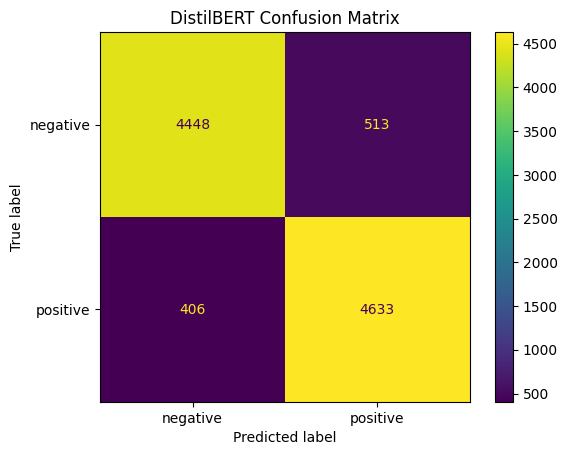

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true_bert,
    y_pred_bert,
    display_labels=['negative', 'positive']
)

plt.title("DistilBERT Confusion Matrix")
plt.show()

In [ ]:
#Compare All Models

In [ ]:
comparison = {
    "Model": ["VADER", "Logistic Regression", "SVM", "DistilBERT"],
    "Accuracy": [vader_accuracy, accuracy, svm_accuracy, bert_accuracy]
}

import pandas as pd

comparison_movie_dataset = pd.DataFrame(comparison)

comparison_movie_dataset

,Model,Accuracy
0,VADER,0.69226
1,Logistic Regression,0.88570
2,SVM,0.88150
3,DistilBERT,0.90810


### **Final Model Selection**

To find the best approach, I tested four different models: VADER, Logistic Regression, SVM, and DistilBERT.

While Logistic Regression and SVM put up a great fight using TF-IDF features, and VADER gave me a decent baseline, **DistilBERT was the clear winner**. Because it's a deep learning transformer model, it didn't just count words—it actually understood the context, sarcasm, and complex language patterns within long movie reviews.

Since DistilBERT achieved the highest accuracy and handles real-world human language the best, I have selected it as the final model for deployment in the Streamlit web app.

In [ ]:
trainer.save_model("distilbert_sentiment_model")

tokenizer.save_pretrained("distilbert_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_sentiment_model/tokenizer_config.json',
 'distilbert_sentiment_model/tokenizer.json')

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.7 MB/s eta 0:00:00


In [ ]:
#Building strealit app
import streamlit as st

st.title("Movie Review Sentiment Analysis")

review = st.text_area("Enter a movie review")

if st.button("Predict"):
    # prediction code
    st.write("Positive")

2026-06-10 18:32:33.591 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:32:33.844 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-10 18:32:33.848 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:32:33.849 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:32:33.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:32:33.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:32:33.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:32:33.860 Thread 'MainThread': mi

### Project Conclusion

### Project Conclusion

This project successfully developed a sentiment analysis system capable of classifying movie reviews using Natural Language Processing (NLP) and Machine Learning techniques. The IMDb movie review dataset was preprocessed through text cleaning, stopword removal, and lemmatization before being transformed into numerical features using TF-IDF.

Multiple sentiment analysis approaches were implemented and evaluated, including VADER, Logistic Regression, Support Vector Machine (SVM), and DistilBERT. The performance comparison demonstrated that transformer-based models such as DistilBERT achieved the highest accuracy due to their ability to capture contextual and semantic relationships within text. Traditional machine learning models, particularly Logistic Regression, also performed strongly while requiring significantly lower computational resources.

A Streamlit-based web application was developed to provide real-time sentiment predictions, enabling users to interact with the trained model through an intuitive interface. This project highlights the importance of data preprocessing, feature engineering, model evaluation, and deployment in building practical NLP solutions.

Future enhancements may include multi-class sentiment classification (Positive, Negative, and Neutral), sarcasm detection, aspect-based sentiment analysis, and deployment on a cloud platform for public access.

In [ ]:
import pickle

pickle.dump(Lr_model, open("logistic_model.pkl", "wb"))

In [ ]:
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

In [ ]:
import os

print(os.listdir())

['.config', 'distilbert_sentiment_model', 'imdb_cleaned.csv', 'tfidf_vectorizer.pkl', 'IMDB Dataset.csv', 'logistic_model.pkl', 'results', 'sample_data']


In [ ]:
from google.colab import files

files.download("logistic_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>